In [1]:
import pandas as pd
import numpy as np

## Load the Breast Cancer Dataset

In [2]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

In [3]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

## Separate Features and target

In [4]:
X = data.data
y = data.target

In [6]:
f"X shape: {X.shape}, y distribution: {np.bincount(y)}"

'X shape: (569, 30), y distribution: [212 357]'

## Split Data into Train and Test

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

In [9]:
f"X_train.shape: {X_train.shape}, np.bincount(y_train): {np.bincount(y_train)},  X_test.shape: {X_test.shape}, np.bincount(y_test): {np.bincount(y_test)}"

'X_train.shape: (455, 30), np.bincount(y_train): [173 282],  X_test.shape: (114, 30), np.bincount(y_test): [39 75]'

## Let's train a Baseline Logistic Regression Model

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


## Baseline Model results

In [16]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91        42
           1       0.93      0.97      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



## Create a Pipeline, with a scaler

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

# Fit on training data
pipe.fit(X_train, y_train)

# Predict on test data
y_pred = pipe.predict(X_test)

# Pipeline Model Results

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Saving your model using joblib

In [19]:
import joblib

joblib.dump(pipe, "breast_cancer_pipeline.pkl")

['breast_cancer_pipeline.pkl']

## Load a saved model using joblib

In [ ]:
loaded_pipe = joblib.load("breast_cancer_pipeline.pkl")
y_pred_loaded = loaded_pipe.predict(X_test)
np.allclose(y_pred_loaded == y_pred)

## Metrics

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[38  4]
 [ 1 71]]


## Normalize the Confusion Matrix, so that each row totals to 1

In [24]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)
print(cm_norm)


[[0.9047619  0.0952381 ]
 [0.01388889 0.98611111]]


## Visualize the Confusion Matrix

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

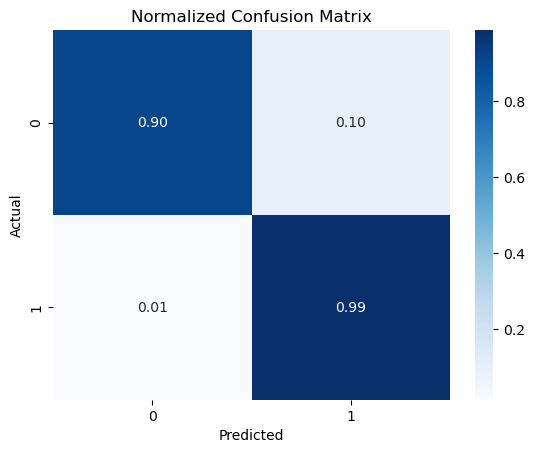

In [29]:
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix")
plt.show()

## ROC Curve and AUC [threshold-independant measure of classifier quality]

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score

In [31]:
y_prob = pipe.predict_proba(X_test)[:, 1]  # probability for class 1 (benign)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)


ROC-AUC: 0.9801587301587302


## Plot the ROC Curve

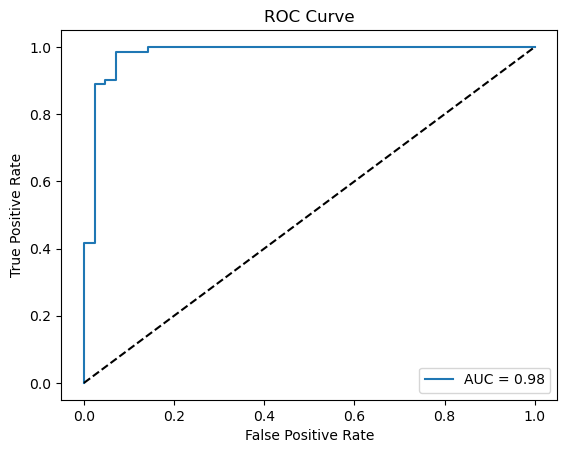

In [33]:
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')  # random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
